# Project Name:Bank Customer Churn Prediction

Every bank wants to hold their customers to sustain their business, so the ABC Multinational Bank.
Below is the customer data of account holders at ABC Multinational Bank and the aim of the data will be to predict the customer churn.

## 1) Import the required Python libraries


In [74]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from scipy import stats
import plotly.express as px

In [75]:
from sklearn.ensemble import IsolationForest
import numpy as np

def detect_outliers(data, columns):
    outlier_indices = []
    for col in columns:
        iso = IsolationForest(contamination=0.05)
        preds = iso.fit_predict(data[[col]])
        outlier_indices.extend(data.index[preds == -1].tolist())
    return list(set(outlier_indices))

## Milestone 1: Data Collection, Exploration, and Preprocessing

### Data Collection

#### Load Project dataset (Bank Customer Churn Prediction)

In [197]:

#df =pd.read_csv('D:\Courses\AI&Datascience\Depi_project\Bank Customer Churn Dataset\Bank Customer Churn Prediction.csv')
df =pd.read_csv('D:\Cours\DataScince\My_Project\Bank Customer Churn Prediction\Bank Customer Churn Prediction.csv')
#pd.set_option('display.max_rows', 5)
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
2,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
3,15592531,822,France,Male,50,7,0.00,2,1,1,10062.80,0
4,15792365,501,France,Male,44,4,142051.07,2,0,1,74940.50,0


In [140]:
#check the last 5 row
df.tail()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
9995,15590213,479,Spain,Male,35,4,125920.98,1,1,1,20393.44,0
9996,15719276,741,Spain,Male,35,6,74371.49,1,0,0,99595.67,0
9997,15588839,606,Spain,Male,30,8,180307.73,2,1,1,1914.41,0
9998,15605622,841,Spain,Male,28,4,0.00,2,1,1,179436.60,0
9999,15657105,726,Spain,Male,36,2,0.00,1,1,0,195192.40,0


### 2.1)check Data Type:

In [141]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

### 2.2)Check and regulate Feature name:

In [142]:
df.columns=df.columns.str.lower().str.strip()
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

### 2.2)Check Data Voulm:

In [143]:
df.size

120000

In [144]:
df.shape

(10000, 12)

In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [146]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [147]:
df.describe(include='O')

,country,gender
count,10000,10000
unique,3,2
top,France,Male
freq,5014,5457


-------------------------

# Step 2: Handle missing values and perform basic data cleaning.

## 2.1)Column Description & Data Cleansing:

The dataset has 10000 records with 12 columns, including 10 continuous and 2 categorical features.

In [148]:
# customer_id not duplicated :
df['customer_id'].nunique() #if result = no of row so the id student uniq

10000

In [149]:
# customer_id, unused variable, so we will drop it from my data:
df.drop('customer_id',axis=1,inplace=True)
df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
2,699,France,Female,39,1,0.00,2,0,0,93826.63,0
3,822,France,Male,50,7,0.00,2,1,1,10062.80,0
4,501,France,Male,44,4,142051.07,2,0,1,74940.50,0


In [150]:
#check null in all feature:
df.isnull().sum()

credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

we do not have any null entry in my data

In [151]:
#2)check data entry of (credit_score) :
df.credit_score.describe()

count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: credit_score, dtype: float64

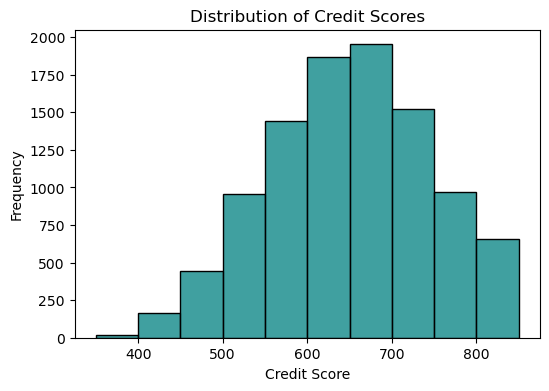

In [152]:

# Create the histogram
plt.figure(figsize=(6, 4))
sns.histplot(df.credit_score, bins=10, color='teal')

# Labels and title
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.title("Distribution of Credit Scores")

# Show plot
plt.show()

In [153]:
#3)country:used as input,
df.country.describe(include='O') #--used to categorical data

count      10000
unique         3
top       France
freq        5014
Name: country, dtype: object

In [154]:
df.country.value_counts()

country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

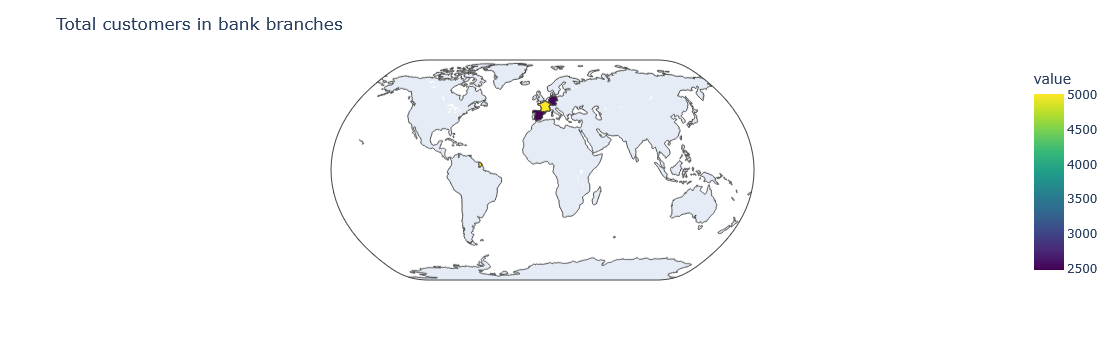

In [155]:
# Display the count of three countries 
data = {'country': ['France', 'Germany', 'Spain'],  
        'value': [5014, 2509, 2477]}  # Different values to affect the color intensity

# Create a DataFrame
df_con = pd.DataFrame(data)

# Create a choropleth map
fig = px.choropleth(df_con, 
                    locations="country", 
                    locationmode="country names",
                    color="value",  # Color intensity based on values
                    hover_name="country",
                    projection="natural earth",
                    color_continuous_scale="Viridis")  # Different colors based on value

# Update layout for a cleaner view
fig.update_layout(title="Total customers in bank branches", geo=dict(showcoastlines=True))

# Show the plot
fig.show()

In [156]:
df.columns

Index(['credit_score', 'country', 'gender', 'age', 'tenure', 'balance',
       'products_number', 'credit_card', 'active_member', 'estimated_salary',
       'churn'],
      dtype='object')

In [157]:
# 4)check the data entry in column (gender)count & category the number of customer by gender:
df.gender.value_counts()

gender
Male      5457
Female    4543
Name: count, dtype: int64

In [158]:
df['gender'].value_counts(normalize=True) * 100


gender
Male      54.57
Female    45.43
Name: proportion, dtype: float64

In [159]:
# 5)check data entry of age :
df.age.value_counts()

age
37    478
38    477
35    474
36    456
34    447
     ... 
92      2
82      1
85      1
83      1
88      1
Name: count, Length: 70, dtype: int64

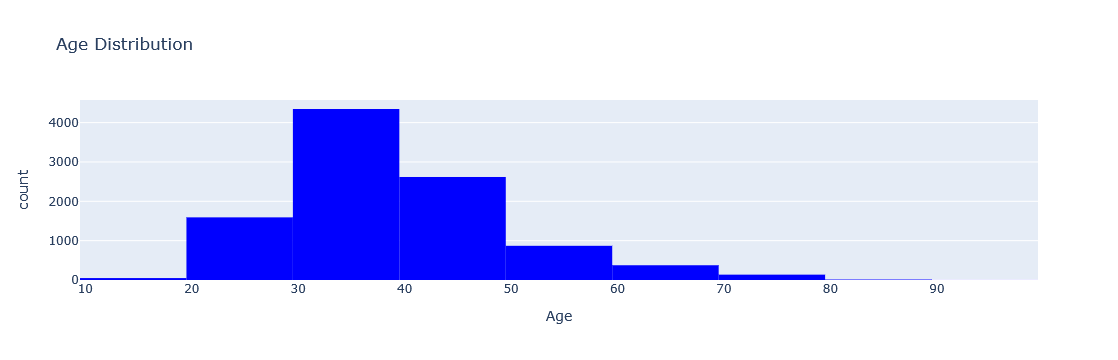

In [160]:


# Create histogram
fig = px.histogram(df, x=df.age, nbins=10, title="Age Distribution", 
                   labels={'age': 'Age'}, 
                   color_discrete_sequence=['blue'])

# Show plot
fig.show()

In [161]:
#6) how many years he/she is having bank acc in ABC Bank
num_year=df.pivot_table(index='tenure',columns='gender',values='age',aggfunc='count')
num_year

gender,Female,Male
tenure,,
0,204,209
1,478,557
2,480,568
3,469,540
4,442,547
5,448,564
6,458,509
7,464,564
8,433,592


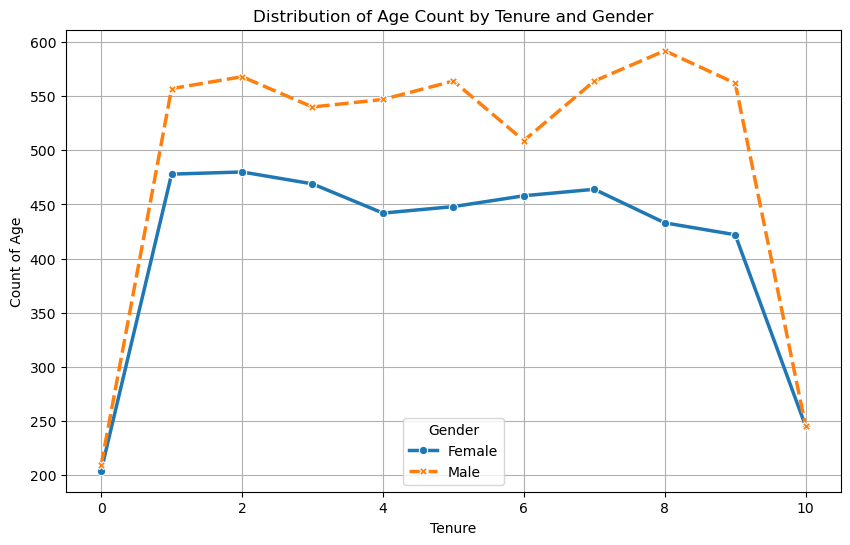

In [162]:
# Creating Pivot Table
num_year = df.pivot_table(index='tenure', columns='gender', values='age', aggfunc='count')

# Plot using Seaborn
plt.figure(figsize=(10, 6))
sns.lineplot(data=num_year, markers=True, linewidth=2.5)


# Customize Plot
plt.xlabel('Tenure')
plt.ylabel('Count of Age')
plt.title('Distribution of Age Count by Tenure and Gender')
plt.legend(title="Gender")
plt.grid(True)

# Show plot
plt.show()

In [163]:
#7) count balance
df.balance.value_counts()

balance
0.00         3617
130170.82       2
105473.74       2
98710.89        1
117633.28       1
             ... 
130385.82       1
127187.86       1
125789.69       1
118307.57       1
180307.73       1
Name: count, Length: 6382, dtype: int64

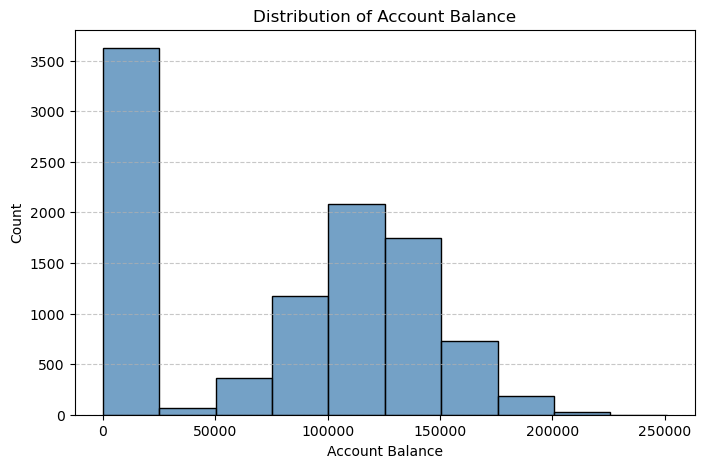

In [164]:
# Plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(df['balance'], bins=10, kde=False, color='steelblue')

# Customize the plot
plt.xlabel('Account Balance')
plt.ylabel('Count')
plt.title('Distribution of Account Balance')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

In [166]:
#8) get the total number of products:
df.products_number.nunique()


4

In [167]:
# count customer per product :
df.products_number.value_counts()

products_number
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

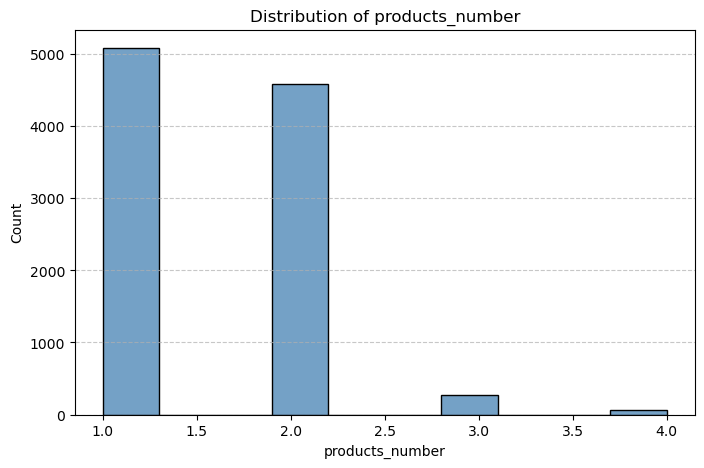

In [168]:
# Plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(df['products_number'], bins=10, kde=False, color='steelblue')

# Customize the plot
plt.xlabel('products_number')
plt.ylabel('Count')
plt.title('Distribution of products_number')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

In [171]:
# i want check Is this customer have credit card ?
df.credit_card.value_counts()

credit_card
1    7055
0    2945
Name: count, dtype: int64

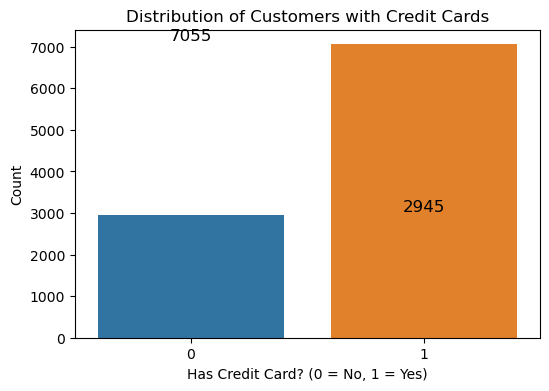

In [172]:
# Sample Data (Replace with actual DataFrame)
credit_card_counts = {1: 7055, 0: 2945}

# Create a bar plot
plt.figure(figsize=(6, 4))
sns.barplot(x=list(credit_card_counts.keys()), y=list(credit_card_counts.values()), palette=['#1f77b4', '#ff7f0e'])

# Labels and Title
plt.xlabel('Has Credit Card? (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.title('Distribution of Customers with Credit Cards')

# Show Values on Bars
for i, v in enumerate(credit_card_counts.values()):
    plt.text(i, v + 100, str(v), ha='center', fontsize=12)

# Show Plot
plt.show()

In [173]:
# i want check Is this customer have credit card ?
df.estimated_salary.value_counts()

estimated_salary
24924.92     2
101348.88    1
163295.87    1
40250.82     1
165990.44    1
            ..
161971.42    1
39488.04     1
187811.71    1
121311.12    1
195192.40    1
Name: count, Length: 9999, dtype: int64

In [174]:
df.estimated_salary.describe()

count     10000.000000
mean     100090.239881
std       57510.492818
min          11.580000
25%       51002.110000
50%      100193.915000
75%      149388.247500
max      199992.480000
Name: estimated_salary, dtype: float64

-----------------------------------------

# Milestone 2: Advanced Data Analysis and Feature Engineering

In [175]:
# drop outlier:
numeric_columns = df.select_dtypes(include=['number']).columns
def detect_outliers_zscore(df, columns, threshold=3):
    outlier_indices = []
    
    for col in columns:
        z_scores = np.abs(stats.zscore(df[col]))
        outliers = df[z_scores > threshold].index
        outlier_indices.extend(outliers)
    
    return list(set(outlier_indices))  # Remove duplicates

# Usage
outliers_indices = detect_outliers_zscore(df, numeric_columns)

print(f"Total Outliers Detected: {len(outliers_indices)}")


Total Outliers Detected: 201


In [176]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)  # First quartile (25%)
    Q3 = df[column].quantile(0.75)  # Third quartile (75%)
    IQR = Q3 - Q1  # Interquartile Range
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Remove outliers
    df_clean = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_clean

# Apply function to the 'balance' column
df_clean = remove_outliers(df, 'balance')

# Display the cleaned dataset
print(df_clean)

      credit_score country  gender  age  tenure    balance  products_number  \
0              619  France  Female   42       2       0.00                1   
1              502  France  Female   42       8  159660.80                3   
2              699  France  Female   39       1       0.00                2   
3              822  France    Male   50       7       0.00                2   
4              501  France    Male   44       4  142051.07                2   
...            ...     ...     ...  ...     ...        ...              ...   
9995           479   Spain    Male   35       4  125920.98                1   
9996           741   Spain    Male   35       6   74371.49                1   
9997           606   Spain    Male   30       8  180307.73                2   
9998           841   Spain    Male   28       4       0.00                2   
9999           726   Spain    Male   36       2       0.00                1   

      credit_card  active_member  estimated_salary 

## Identify correlations and patterns in customer performance

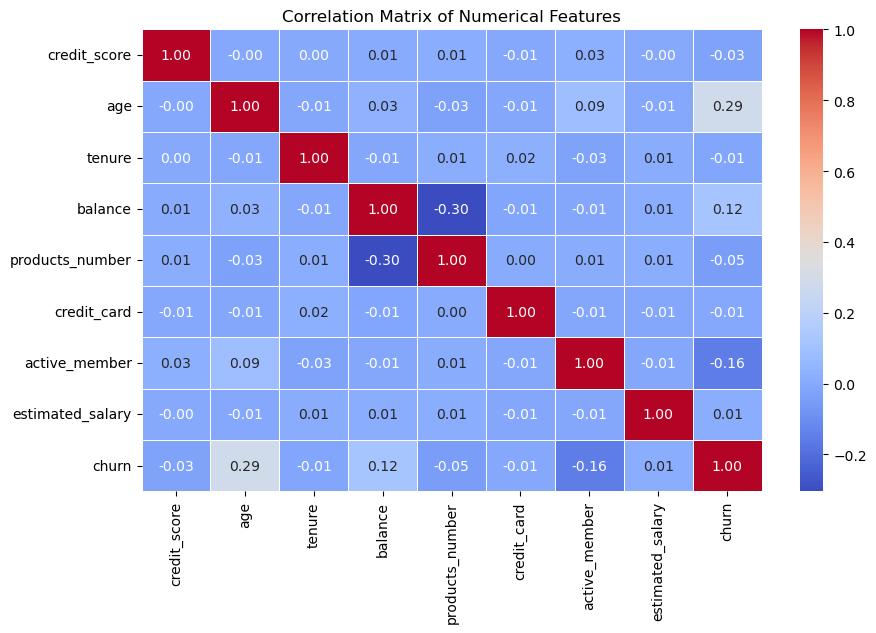

In [177]:
numeric_columns = df.select_dtypes(include=['number'])
corr_matrix = numeric_columns.corr()

# Visualize the correlation using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

#### 1)Customer vs Churn Rate by Age:

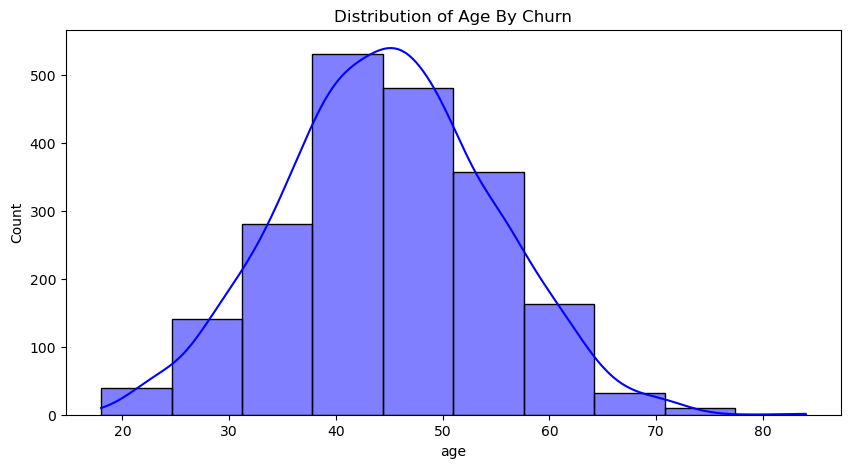

In [178]:

plt.figure(figsize=(10, 5))
sns.histplot(df['age'][df['churn'] == 1], bins=10, kde=True, color="blue")
plt.title('Distribution of Age By Churn')
plt.show()

#### 2)Active Customer vs Churn :

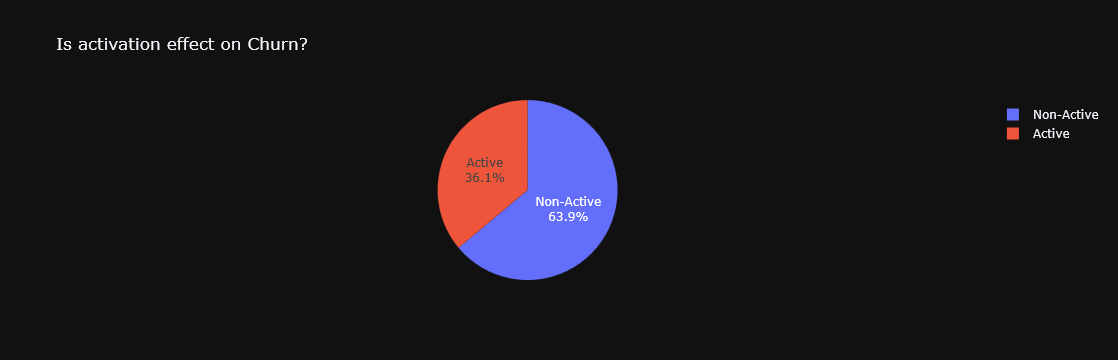

In [181]:
val=df['active_member'][df['churn']==1].value_counts().values
index=df['active_member'][df['churn']==1].value_counts().index
index = index.to_series().replace({0: "Non-Active", 1: "Active"})
fig = px.pie(
             values=val,
             names=index,
             template='plotly_dark',
             title='Is activation effect on Churn?'
            ).update_traces(textinfo='label+percent')
fig.show()

In [ ]:
#### 3)Total  Customer vs Churn ber country :

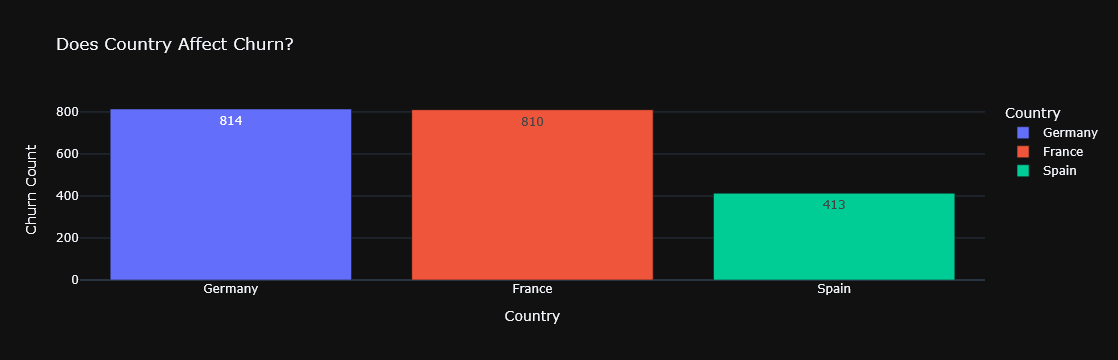

In [182]:
# Count churned customers per country
churn_counts = df['country'][df['churn'] == 1].value_counts().reset_index()
churn_counts.columns = ['Country', 'Count']

# Create a colorful Plotly bar chart
fig = px.bar(churn_counts, 
             x='Country', 
             y='Count',
             template='plotly_dark',
             labels={'Count': 'Churn Count', 'Country': 'Country'},
             text_auto=True,
             color='Country',  # Different colors for each country
             title='Does Country Affect Churn?')

# Show the plot
fig.show()

In [184]:
df.columns

Index(['credit_score', 'country', 'gender', 'age', 'tenure', 'balance',
       'products_number', 'credit_card', 'active_member', 'estimated_salary',
       'churn'],
      dtype='object')

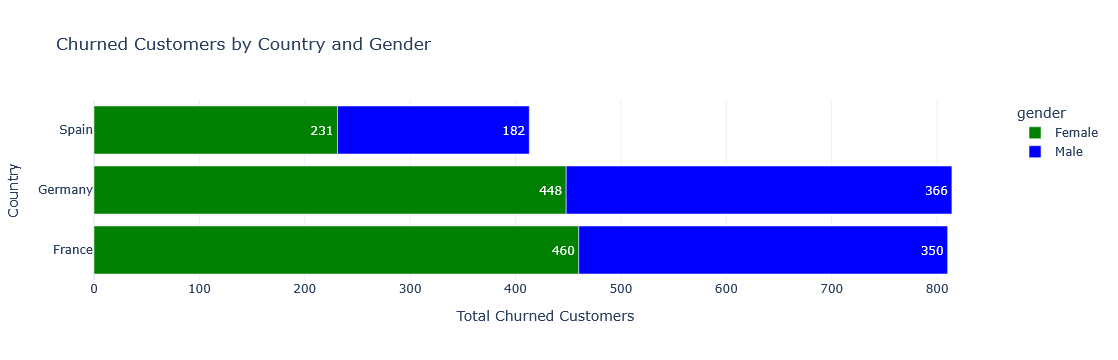

In [199]:

# Filter data for churned customers only (churn = 1)
df_churned = df[df['churn'] == 1]

# Group the dataset by country and gender, counting the number of churned customers
df_grouped = df_churned.groupby(['country', 'gender']).size().reset_index(name='churned_customers')

# Create the stacked horizontal bar chart
fig = px.bar(df_grouped, 
             x='churned_customers', 
             y='country', 
             color='gender', 
             text='churned_customers',
             orientation='h',
             title='Churned Customers by Country and Gender',
             labels={'churned_customers': 'Total Churned Customers', 'country': 'Country'},
             color_discrete_map={'Female': 'green', 'Male': 'blue'}  # Custom colors
             )

# Update layout for better readability
fig.update_layout(barmode='relative', template='plotly_white')

# Show plot
fig.show()

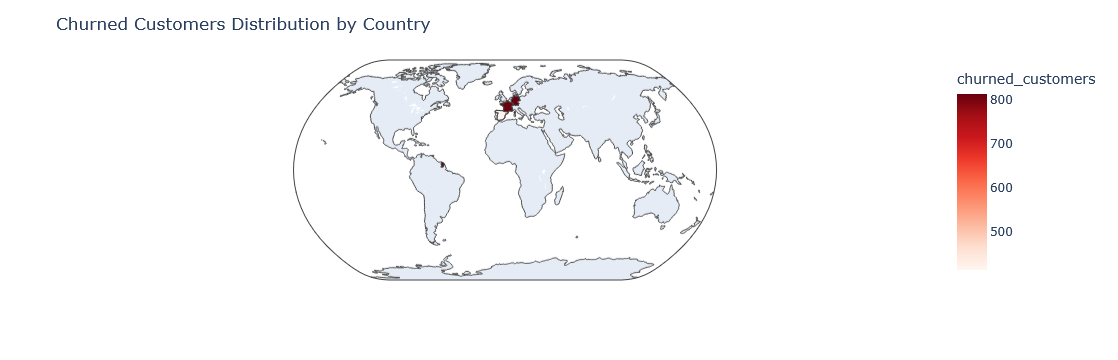

In [200]:
# Filter data for churned customers only (churn = 1)
df_churned = df[df['churn'] == 1]

# Count churned customers by country
df_con = df_churned['country'].value_counts().reset_index()
df_con.columns = ['country', 'churned_customers']

# Create a choropleth map
fig = px.choropleth(df_con, 
                    locations="country", 
                    locationmode="country names",
                    color="churned_customers",  # Color intensity based on churn count
                    hover_name="country",
                    projection="natural earth",
                    color_continuous_scale="Reds")  # Red color scale for churn intensity

# Update layout for better visualization
fig.update_layout(title="Churned Customers Distribution by Country", 
                  geo=dict(showcoastlines=True))

# Show the plot
fig.show()